# Space Shuttle Challenger O-Ring Risk Analysis

## Case Study

The Space Shuttle Challenger disaster highlighted the importance of understanding the relationship between environmental conditions and engineering risk.

This analysis uses historical Space Shuttle launch data to examine whether **launch temperature** is related to the probability of **O-ring damage**.

The response variable is binary:

- **0 = No O-ring damage**
- **1 = O-ring damage**

Because the response variable has two possible outcomes, **logistic regression** is used to model the probability of O-ring damage.

## Dataset Description

The dataset contains **24 previous Space Shuttle launches**.

The variables are:

- **Flight Number:** Identifier of the Space Shuttle mission.
- **Launch Temperature:** Temperature at the time of launch, measured in degrees Fahrenheit.
- **Damage to O-ring:** Binary variable indicating whether O-ring damage occurred.
  - 0 = No damage
  - 1 = Damage

## Research Questions

1. Is launch temperature statistically related to O-ring damage?
2. Develop a logistic regression model to estimate the probability of O-ring damage based on launch temperature.
3. Interpret the coefficient of launch temperature.
4. Calculate and interpret the odds ratio for launch temperature.
5. Estimate the probability of O-ring damage at different launch temperatures.
6. Estimate the probability of O-ring damage at the Challenger launch temperature of 36°F.
7. Visualize how the probability of O-ring damage changes with launch temperature.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Statsmodels
- Logistic Regression

SPACE SHUTTLE CHALLENGER O-RING RISK ANALYSIS

Dataset successfully loaded.

Number of observations:
24

First five observations:


,Flight Number,Launch Temperature,Damage to O-ring
0,STS 1,66,0
1,STS 2,70,1
2,STS 3,69,0
3,STS 4,80,0
4,STS 5,68,0



Column names:
['Flight Number', 'Launch Temperature', 'Damage to O-ring']

DATASET OVERVIEW

Missing Values:
Flight_Number         0
Launch_Temperature    0
O_Ring_Damage         0
dtype: int64

Descriptive Statistics:


,Launch_Temperature,O_Ring_Damage
count,24.000000,24.000000
mean,70.000000,0.291667
std,7.223151,0.464306
min,53.000000,0.000000
25%,67.000000,0.000000
50%,70.000000,0.000000
75%,75.250000,1.000000
max,81.000000,1.000000



O-RING DAMAGE SUMMARY

Number of launches with no O-ring damage:
17

Number of launches with O-ring damage:
7

Average launch temperature by O-ring damage status:


,Launch_Temperature
O_Ring_Damage,
0,72.588235
1,63.714286


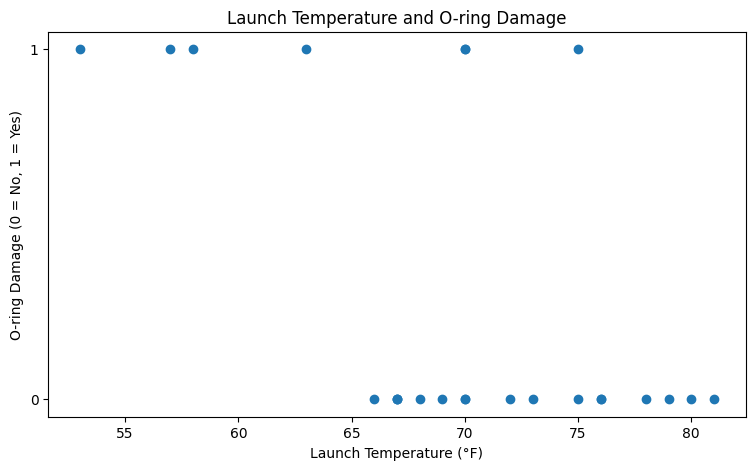


QUESTION 1
IS LAUNCH TEMPERATURE RELATED TO O-RING DAMAGE?

Logistic Regression Results:
                           Logit Regression Results                           
Dep. Variable:          O_Ring_Damage   No. Observations:                   24
Model:                          Logit   Df Residuals:                       22
Method:                           MLE   Df Model:                            1
Date:                Sun, 06 Sep 2026   Pseudo R-squ.:                  0.2969
Time:                        19:02:54   Log-Likelihood:                -10.186
converged:                       True   LL-Null:                       -14.487
Covariance Type:            nonrobust   LLR p-value:                  0.003356
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 15.2968      7.329      2.087      0.037       0.933      29.661
Launch_Temperatur

,Launch_Temperature,Predicted_Probability,Probability_Percent
0,36,0.998888,99.888754
1,40,0.997145,99.714546
2,50,0.970567,97.056743
3,53,0.942008,94.200844
4,57,0.863378,86.337793
5,60,0.756866,75.686571
6,65,0.488869,48.886893
7,70,0.227122,22.712178
8,75,0.082812,8.281206
9,80,0.026992,2.699225



QUESTION 6
PREDICTED RISK AT CHALLENGER LAUNCH TEMPERATURE

Challenger launch temperature: 36°F
Predicted probability of O-ring damage: 0.9989
Predicted probability as percentage: 99.89%

Interpretation:
The logistic regression model estimates the probability of O-ring damage at the very low launch temperature experienced by Challenger.

QUESTION 7
LOGISTIC REGRESSION RISK CURVE


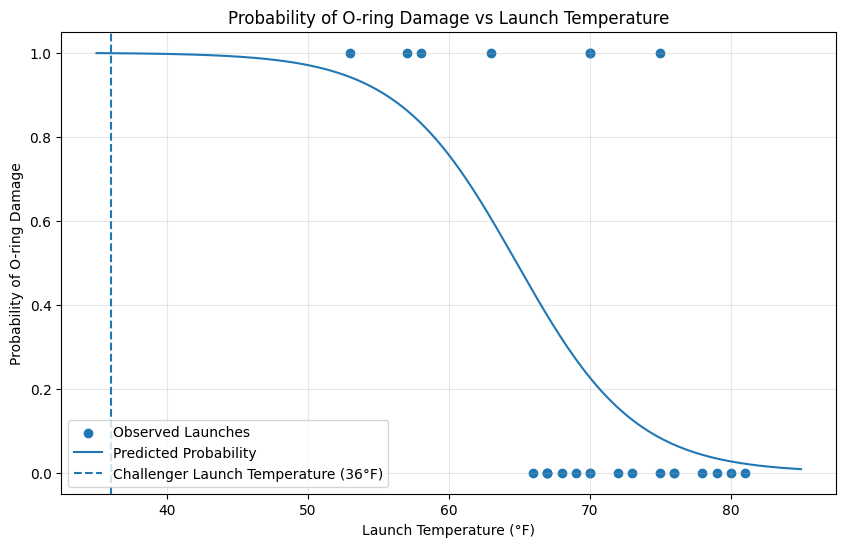


FINAL RESULTS SUMMARY

Logistic Regression Equation:
log(p/(1-p)) = 15.2968 + (-0.2360 × Temperature)

Temperature P-value: 0.0279
Odds Ratio: 0.7898
Predicted Probability of O-ring Damage at 36°F: 99.89%

Overall Interpretation:
The fitted logistic regression model shows how launch temperature is associated with the probability of O-ring damage. A negative temperature coefficient indicates that colder launch conditions are associated with a higher estimated risk of O-ring damage.


In [1]:
# ============================================================
# SPACE SHUTTLE CHALLENGER O-RING RISK ANALYSIS
# Logistic Regression
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ------------------------------------------------------------
# 2. LOAD DATA FROM EXCEL FILE
# ------------------------------------------------------------

file_name = "Space_Shuttle_Challenger_O_Ring_Data.xlsx"

df = pd.read_excel(
    file_name,
    sheet_name="Challenger Raw Data"
)

print("=" * 70)
print("SPACE SHUTTLE CHALLENGER O-RING RISK ANALYSIS")
print("=" * 70)

print("\nDataset successfully loaded.")

print("\nNumber of observations:")
print(len(df))

print("\nFirst five observations:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 3. DATA PREPARATION
# ------------------------------------------------------------

df.columns = [
    "Flight_Number",
    "Launch_Temperature",
    "O_Ring_Damage"
]

df["Launch_Temperature"] = pd.to_numeric(
    df["Launch_Temperature"],
    errors="coerce"
)

df["O_Ring_Damage"] = pd.to_numeric(
    df["O_Ring_Damage"],
    errors="coerce"
)

df = df.dropna()

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe())


# ------------------------------------------------------------
# 4. BASIC DATA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("O-RING DAMAGE SUMMARY")
print("=" * 70)

damage_counts = df["O_Ring_Damage"].value_counts().sort_index()

print("\nNumber of launches with no O-ring damage:")
print(damage_counts.get(0, 0))

print("\nNumber of launches with O-ring damage:")
print(damage_counts.get(1, 0))


print("\nAverage launch temperature by O-ring damage status:")

display(
    df.groupby("O_Ring_Damage")[
        "Launch_Temperature"
    ].mean()
)


# ------------------------------------------------------------
# 5. VISUALIZE OBSERVED DATA
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Launch_Temperature"],
    df["O_Ring_Damage"]
)

plt.xlabel("Launch Temperature (°F)")
plt.ylabel("O-ring Damage (0 = No, 1 = Yes)")
plt.title("Launch Temperature and O-ring Damage")

plt.yticks([0, 1])

plt.show()


# ============================================================
# QUESTION 1
# IS LAUNCH TEMPERATURE RELATED TO O-RING DAMAGE?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 1")
print("IS LAUNCH TEMPERATURE RELATED TO O-RING DAMAGE?")
print("=" * 70)


# ------------------------------------------------------------
# 6. BUILD LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

X = sm.add_constant(
    df["Launch_Temperature"]
)

y = df["O_Ring_Damage"]


logit_model = sm.Logit(
    y,
    X
)

result = logit_model.fit(
    disp=False
)


print("\nLogistic Regression Results:")

print(
    result.summary()
)


temperature_pvalue = result.pvalues[
    "Launch_Temperature"
]


print("\nHypotheses:")

print(
    "H0: Launch temperature has no statistically significant "
    "relationship with O-ring damage."
)

print(
    "H1: Launch temperature has a statistically significant "
    "relationship with O-ring damage."
)


print(
    f"\nP-value for Launch Temperature: "
    f"{temperature_pvalue:.4f}"
)


if temperature_pvalue < 0.05:

    print(
        "\nConclusion: Reject H0."
    )

    print(
        "There is statistically significant evidence that "
        "launch temperature is related to the probability "
        "of O-ring damage."
    )

else:

    print(
        "\nConclusion: Fail to reject H0."
    )

    print(
        "There is insufficient statistical evidence at the "
        "5% significance level to conclude that launch "
        "temperature is related to O-ring damage."
    )


# ============================================================
# QUESTION 2
# LOGISTIC REGRESSION EQUATION
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 2")
print("LOGISTIC REGRESSION EQUATION")
print("=" * 70)


intercept = result.params[
    "const"
]

temperature_coefficient = result.params[
    "Launch_Temperature"
]


print(
    f"\nIntercept: "
    f"{intercept:.6f}"
)

print(
    f"Launch Temperature Coefficient: "
    f"{temperature_coefficient:.6f}"
)


print("\nEstimated Logistic Regression Model:")

print(
    f"log(p / (1-p)) = "
    f"{intercept:.6f} "
    f"+ ({temperature_coefficient:.6f} × Launch Temperature)"
)


print(
    "\nwhere p represents the probability of O-ring damage."
)


# ============================================================
# QUESTION 3
# INTERPRET THE TEMPERATURE COEFFICIENT
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 3")
print("INTERPRETATION OF TEMPERATURE COEFFICIENT")
print("=" * 70)


print(
    f"\nEstimated coefficient: "
    f"{temperature_coefficient:.6f}"
)


if temperature_coefficient < 0:

    print(
        "\nInterpretation:"
    )

    print(
        "The negative coefficient indicates that as launch "
        "temperature increases, the log-odds and probability "
        "of O-ring damage decrease."
    )

    print(
        "Therefore, lower launch temperatures are associated "
        "with a greater risk of O-ring damage."
    )

else:

    print(
        "\nInterpretation:"
    )

    print(
        "The positive coefficient indicates that higher "
        "launch temperatures are associated with greater "
        "odds of O-ring damage."
    )


# ============================================================
# QUESTION 4
# ODDS RATIO
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 4")
print("ODDS RATIO")
print("=" * 70)


odds_ratio = np.exp(
    temperature_coefficient
)


print(
    f"\nOdds Ratio for a 1°F increase in temperature: "
    f"{odds_ratio:.4f}"
)


percent_change = (
    odds_ratio - 1
) * 100


print(
    f"\nApproximate percentage change in the odds of O-ring "
    f"damage for each 1°F increase in launch temperature: "
    f"{percent_change:.2f}%"
)


if odds_ratio < 1:

    print(
        "\nInterpretation:"
    )

    print(
        "For each 1°F increase in launch temperature, "
        "the odds of O-ring damage decrease."
    )


# ============================================================
# QUESTION 5
# PREDICTED PROBABILITIES AT DIFFERENT TEMPERATURES
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 5")
print("PREDICTED PROBABILITIES AT DIFFERENT TEMPERATURES")
print("=" * 70)


temperature_values = pd.DataFrame({
    "Launch_Temperature": [
        36,
        40,
        50,
        53,
        57,
        60,
        65,
        70,
        75,
        80
    ]
})


X_prediction = sm.add_constant(
    temperature_values,
    has_constant="add"
)


temperature_values[
    "Predicted_Probability"
] = result.predict(
    X_prediction
)


temperature_values[
    "Probability_Percent"
] = (
    temperature_values[
        "Predicted_Probability"
    ] * 100
)


display(
    temperature_values
)


# ============================================================
# QUESTION 6
# CHALLENGER LAUNCH AT 36°F
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 6")
print("PREDICTED RISK AT CHALLENGER LAUNCH TEMPERATURE")
print("=" * 70)


challenger_temperature = 36


challenger_data = pd.DataFrame({
    "const": [1],
    "Launch_Temperature": [
        challenger_temperature
    ]
})


challenger_probability = result.predict(
    challenger_data
)[0]


print(
    f"\nChallenger launch temperature: "
    f"{challenger_temperature}°F"
)


print(
    f"Predicted probability of O-ring damage: "
    f"{challenger_probability:.4f}"
)


print(
    f"Predicted probability as percentage: "
    f"{challenger_probability * 100:.2f}%"
)


print(
    "\nInterpretation:"
)

print(
    "The logistic regression model estimates the probability "
    "of O-ring damage at the very low launch temperature "
    "experienced by Challenger."
)


# ============================================================
# QUESTION 7
# LOGISTIC REGRESSION CURVE
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 7")
print("LOGISTIC REGRESSION RISK CURVE")
print("=" * 70)


temperature_range = np.linspace(
    35,
    85,
    300
)


prediction_data = pd.DataFrame({
    "const": np.ones(
        len(temperature_range)
    ),

    "Launch_Temperature":
        temperature_range
})


predicted_probability = result.predict(
    prediction_data
)


plt.figure(figsize=(10, 6))


plt.scatter(
    df["Launch_Temperature"],
    df["O_Ring_Damage"],
    label="Observed Launches"
)


plt.plot(
    temperature_range,
    predicted_probability,
    label="Predicted Probability"
)


plt.axvline(
    36,
    linestyle="--",
    label="Challenger Launch Temperature (36°F)"
)


plt.xlabel(
    "Launch Temperature (°F)"
)

plt.ylabel(
    "Probability of O-ring Damage"
)

plt.title(
    "Probability of O-ring Damage vs Launch Temperature"
)

plt.ylim(
    -0.05,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)


print(
    f"\nLogistic Regression Equation:"
)

print(
    f"log(p/(1-p)) = "
    f"{intercept:.4f} "
    f"+ ({temperature_coefficient:.4f} × Temperature)"
)


print(
    f"\nTemperature P-value: "
    f"{temperature_pvalue:.4f}"
)


print(
    f"Odds Ratio: "
    f"{odds_ratio:.4f}"
)


print(
    f"Predicted Probability of O-ring Damage "
    f"at 36°F: "
    f"{challenger_probability * 100:.2f}%"
)


print(
    "\nOverall Interpretation:"
)

print(
    "The fitted logistic regression model shows how launch "
    "temperature is associated with the probability of "
    "O-ring damage. A negative temperature coefficient "
    "indicates that colder launch conditions are associated "
    "with a higher estimated risk of O-ring damage."
)

# Conclusion and Key Findings

This project used logistic regression to investigate the relationship between launch temperature and O-ring damage in historical Space Shuttle missions.

The analysis demonstrates that launch temperature is an important variable for assessing O-ring failure risk. The estimated logistic regression coefficient for launch temperature indicates that colder launch conditions are associated with a greater probability of O-ring damage.

The odds ratio provides an additional interpretation of the model by showing how the odds of O-ring damage change for every one-degree Fahrenheit increase in launch temperature.

The fitted model was also used to calculate predicted probabilities of O-ring damage across different launch temperatures. Of particular interest is the Challenger launch temperature of **36°F**, which was substantially lower than the temperatures represented by most previous launches. The model can therefore be used to estimate the elevated risk associated with such unusually cold conditions.

The logistic regression curve provides a visual representation of the relationship, showing that the predicted probability of O-ring damage rises as launch temperature falls.

Overall, this case demonstrates how logistic regression can be applied to engineering and risk-analysis problems where the outcome is binary. It also illustrates the importance of incorporating environmental conditions into safety-related decision making.